<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP3-Co24.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [ ]:
# Librerias

import gdown
import zipfile
import os
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


In [1]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=18d376a9-7037-41e0-a64e-d8acda5ab869
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 35.0MB/s]


In [3]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- VALIDATION (TEST) ---")
val_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_VAL)):
    ruta_clase = os.path.join(DATASET_ROOT_VAL, clase)
    if os.path.isdir(ruta_clase):
        val_counts[clase] = len(os.listdir(ruta_clase))

total_val = sum(val_counts.values())
for clase, cantidad in val_counts.items():
    porcentaje = (cantidad / total_val) * 100 if total_val > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Validation: {total_val}")

--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- VALIDATION (TEST) ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Validation: 3068


- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
Opción 0 (o inválida). Clase elegida al azar.
--- METADATA DE LAS IMÁGENES (TRISTEZA) ---
[1] Archivo: train_08235_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_02861_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_00671_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_05699_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


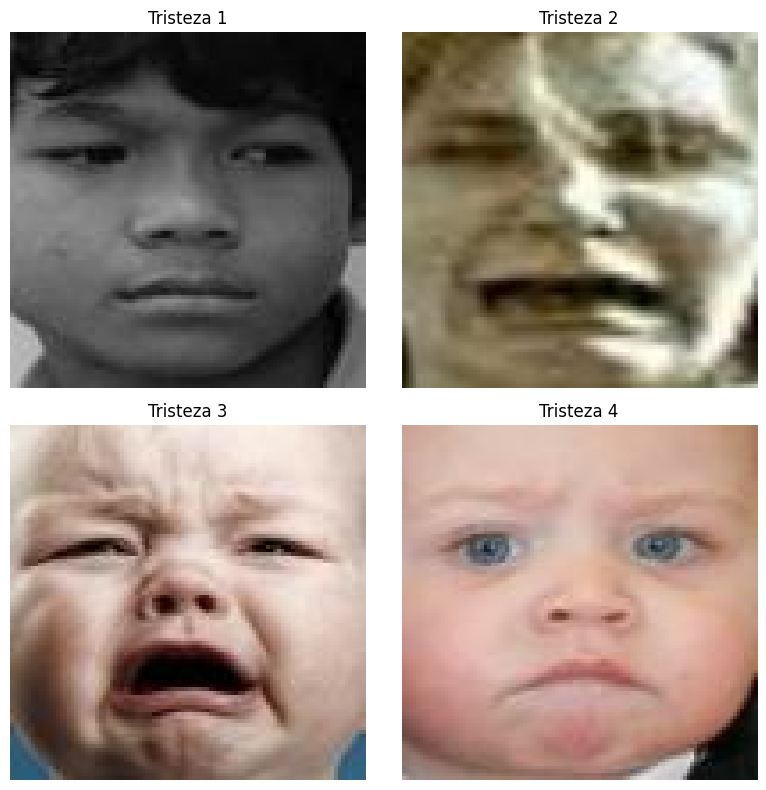

In [100]:
# VISUALIZADOR
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 0 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")

- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
